In [ ]:
# !pip install opencv-python
# !pip install matplotlib
# !pip install scikit-image
from google.colab import drive
from pathlib import Path
drive.mount('/content/drive')
BASE = Path("/content/drive/My Drive/Segmentation notebook")

import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.measure import label, regionprops
import imageio.v2 as imageio

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# SELECT IMAGE
# IMAGE_FILE = BASE / "12122_microscópioOlympus_40x_1.tif"          # Local path to the image
# MASK_FILE = BASE / "12122_microscópioOlympus_40x_1_seg.npy"        # Local path to the Cellpose mask

# IMAGE_FILE = BASE / "12122_microscópioOlympus_40x_2.tif"          # Local path to the image
# MASK_FILE = BASE / "12122_microscópioOlympus_40x_2_seg.npy"        # Local path to the Cellpose mask

# IMAGE_FILE = BASE / "12122_microscópioOlympus_40x_3.tif"          # Local path to the image
# MASK_FILE = BASE / "12122_microscópioOlympus_40x_3_seg.npy"        # Local path to the Cellpose mask

# IMAGE_FILE = BASE / "12122_microscópioOlympus_40x_4.tif"          # Local path to the image
# MASK_FILE = BASE / "12122_microscópioOlympus_40x_4_seg.npy"        # Local path to the Cellpose mask

IMAGE_FILE = BASE / "12122_microscópioOlympus_40x_5.tif"          # Local path to the image
MASK_FILE = BASE / "12122_microscópioOlympus_40x_5_seg.npy"        # Local path to the Cellpose mask

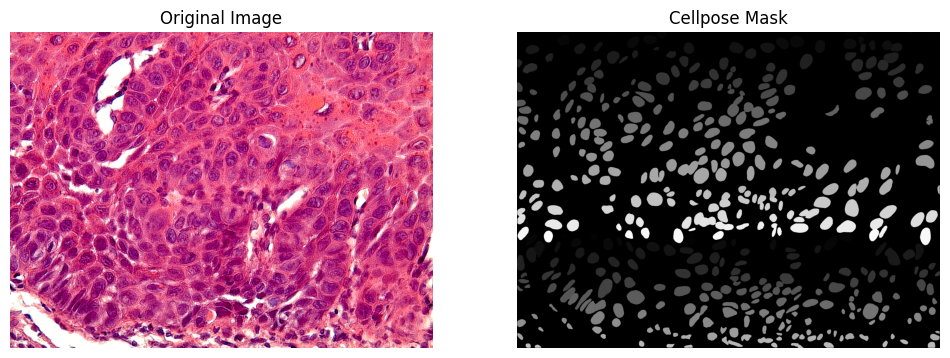

Detected 414 nuclei.
Prepared 36 nuclei crops.


In [ ]:
# ==== Parameters ====
BOX_SIZE = 50
NUCLEI_TO_SHOW = 36
GRID_SIZE = 6  # for plotting

# ==== Load image robustly ====
def load_image(file_path):
    img = imageio.imread(file_path)
    # Handle multi-page TIFF or channel-first images
    if img.ndim == 4:
        img = img[0]
    elif img.ndim == 3 and img.shape[0] <= 4:  # possible channel-first
        img = np.transpose(img, (1, 2, 0))
    # Convert grayscale to RGB
    if img.ndim == 2:
        img_rgb = np.stack([img] * 3, axis=-1)
    elif img.ndim == 3 and img.shape[2] in [1, 2]:
        img_rgb = np.repeat(img[:, :, :1], 3, axis=2)
    else:
        img_rgb = img
    return img, img_rgb

# ==== Load image and mask ====
image, image_rgb = load_image(IMAGE_FILE)
mask_dict = np.load(MASK_FILE, allow_pickle=True).item()  # Cellpose output stored as dict
mask = mask_dict['masks']  # adjust key if different

# ==== Optional display original image and mask ====
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(image_rgb.astype(np.uint8))
axes[0].set_title("Original Image")
axes[0].axis('off')

axes[1].imshow(mask.astype(np.uint8), cmap='gray')
axes[1].set_title("Cellpose Mask")
axes[1].axis('off')
plt.show()

# ==== Label nuclei ====
labeled_mask = label(mask > 0)
regions = regionprops(labeled_mask)
print(f"Detected {len(regions)} nuclei.")

# ==== Extract individual nuclei ====
nuc_ids = np.unique(mask)
nuc_ids = nuc_ids[nuc_ids != 0]  # remove background

nuclei_color = []
nuclei_gray_norm = []
nuclei_blue_inv = []

for nuc_id in nuc_ids[:NUCLEI_TO_SHOW]:
    ys, xs = np.where(mask == nuc_id)
    if len(ys) == 0 or len(xs) == 0:
        continue

    minr, maxr = ys.min(), ys.max() + 1
    minc, maxc = xs.min(), xs.max() + 1

    crop = image[minr:maxr, minc:maxc]
    region_mask = (mask[minr:maxr, minc:maxc] == nuc_id).astype(np.uint8)

    # === Apply mask ===
    if crop.ndim == 2:
        crop_masked = crop * region_mask
        crop_rgb = np.stack([crop_masked]*3, axis=-1)
        crop_gray = crop_masked.astype(np.float32)
    else:
        crop_masked = crop * region_mask[:, :, np.newaxis]
        crop_rgb = crop_masked
        # drop alpha channel if present
        if crop_rgb.shape[2] == 4:
            crop_rgb = crop_rgb[:, :, :3]
        crop_gray = cv2.cvtColor(crop_rgb, cv2.COLOR_BGR2GRAY).astype(np.float32)

    # === Resize if needed ===
    h, w = crop_rgb.shape[:2]
    if max(h, w) > BOX_SIZE:
        scale = BOX_SIZE / max(h, w)
        crop_rgb = cv2.resize(crop_rgb, (int(w * scale), int(h * scale)))
        crop_gray = cv2.resize(crop_gray, (int(w * scale), int(h * scale)))
        region_mask = cv2.resize(region_mask, (int(w * scale), int(h * scale)), interpolation=cv2.INTER_NEAREST)
        h, w = crop_rgb.shape[:2]

    # === Centering offsets ===
    y_offset = (BOX_SIZE - h) // 2
    x_offset = (BOX_SIZE - w) // 2

    # ---- Color image ----
    box_color = np.zeros((BOX_SIZE, BOX_SIZE, 3), dtype=np.uint8)
    box_color[y_offset:y_offset + h, x_offset:x_offset + w] = crop_rgb
    nuclei_color.append(box_color)

    # ---- Grayscale normalized ----
    total_intensity = crop_gray.sum()
    if total_intensity > 0:
        crop_gray /= total_intensity
    box_gray = np.zeros((BOX_SIZE, BOX_SIZE), dtype=np.float32)
    box_gray[y_offset:y_offset + h, x_offset:x_offset + w] = crop_gray
    nuclei_gray_norm.append(box_gray)

    # ---- Inverted blue channel ----
    blue_channel = crop_rgb[..., 2].astype(np.float32)
    blue_inv = (255 - blue_channel) * region_mask
    blue_inv = np.clip(blue_inv, 0, 255)
    total_intensity2 = blue_inv.sum()
    if total_intensity2 > 0:
        blue_inv /= total_intensity2
    box_blue_inv = np.zeros((BOX_SIZE, BOX_SIZE), dtype=np.float32)
    box_blue_inv[y_offset:y_offset + h, x_offset:x_offset + w] = blue_inv
    nuclei_blue_inv.append(box_blue_inv)

print(f"Prepared {len(nuclei_color)} nuclei crops.")


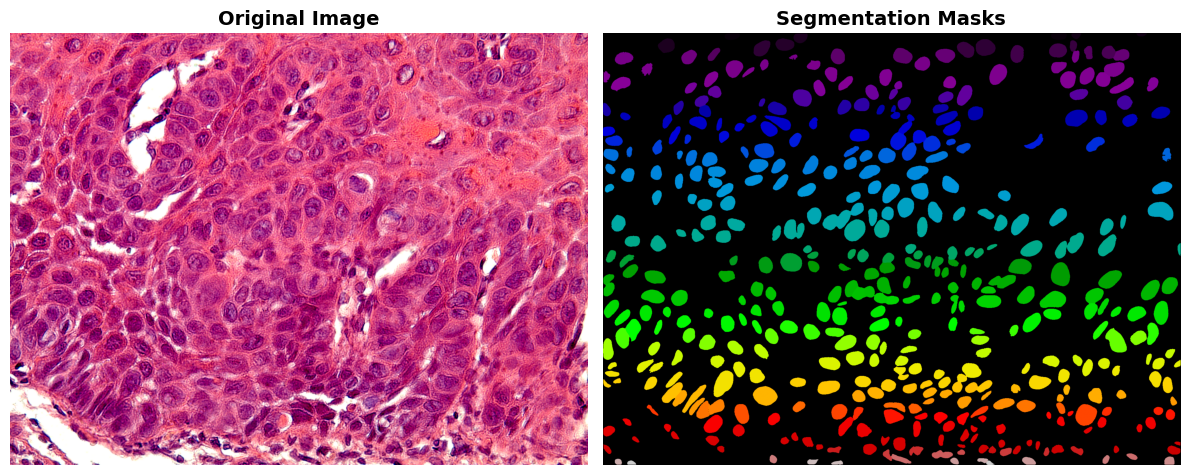

Created overlay visualizations with 414 detected nuclei


In [ ]:
# ==== Create overlay visualization ====
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches

# Create a colored overlay of masks on the original image
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# 1. Original image
axes[0].imshow(image_rgb.astype(np.uint8))
axes[0].set_title("Original Image", fontsize=14, fontweight='bold')
axes[0].axis('off')

# 2. Mask only
axes[1].imshow(mask, cmap='nipy_spectral')
axes[1].set_title("Segmentation Masks", fontsize=14, fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.show()

print(f"Created overlay visualizations with {len(regions)} detected nuclei")

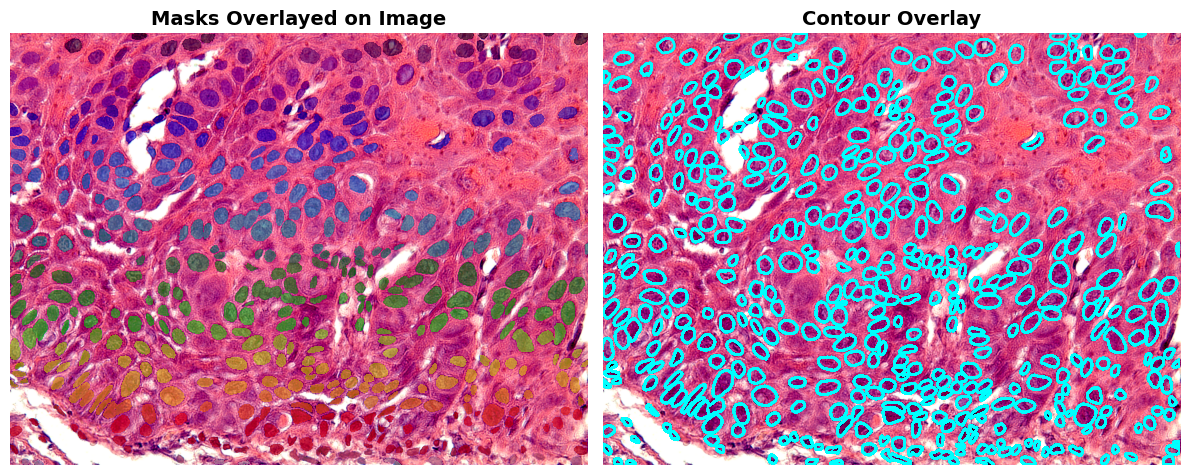

Created overlay visualizations with 414 detected nuclei


In [ ]:
# ==== Alternative: Overlay with contours ====
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# 3. Overlay - masks on original image
axes[0].imshow(image_rgb.astype(np.uint8))
# Create a colored mask overlay with transparency
mask_colored = np.ma.masked_where(mask == 0, mask)
axes[0].imshow(mask_colored, cmap='nipy_spectral', alpha=0.5, interpolation='none')
axes[0].set_title("Masks Overlayed on Image", fontsize=14, fontweight='bold')
axes[0].axis('off')

# Overlay with contours only
axes[1].imshow(image_rgb.astype(np.uint8))
from skimage import segmentation
boundaries = segmentation.find_boundaries(mask, mode='outer')
axes[1].contour(mask, levels=np.unique(mask)[1:], colors='cyan', linewidths=1.5)
axes[1].set_title("Contour Overlay", fontsize=14, fontweight='bold')
axes[1].axis('off')
axes[1].set_aspect('equal')

plt.tight_layout()
plt.show()

print(f"Created overlay visualizations with {len(regions)} detected nuclei")

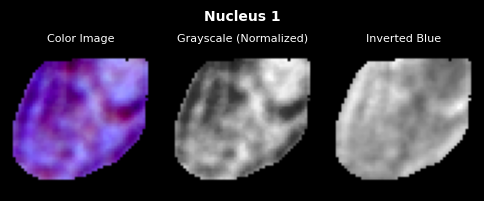

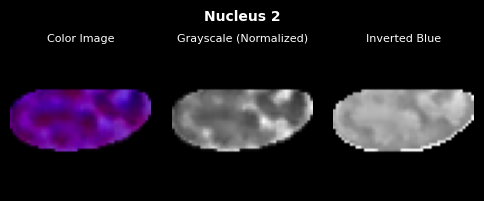

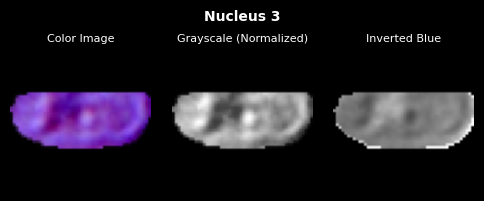

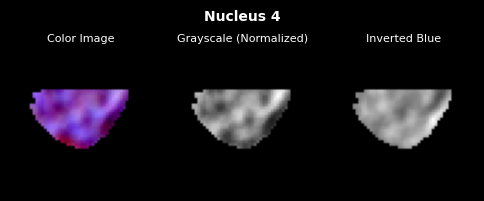

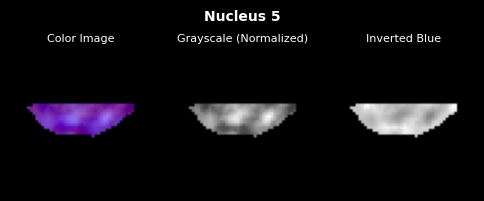

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ==== Helper function ====
def show_nuclei_triplet(nuclei_color, nuclei_gray_norm,nuclei_blue_inv, num_to_show=10):
    """
    Show side-by-side triplets: Color | Grayscale | Inverted Blue
    """
    num_to_show = min(num_to_show, len(nuclei_color), len(nuclei_gray_norm))

    for i in range(num_to_show):
        color_img = cv2.cvtColor(nuclei_color[i], cv2.COLOR_BGR2RGB)

        gray_img = nuclei_gray_norm[i]
        gray_norm = gray_img / gray_img.max() if gray_img.max() > 0 else gray_img
        inv_blue=nuclei_blue_inv[i]
        # Create inverted blue channel image

        # === Plot ===
        fig, axes = plt.subplots(1, 3, figsize=(5, 2))
        fig.suptitle(f"Nucleus {i+1}", fontsize=10, color='white', weight='bold')

        # Color
        axes[0].imshow(color_img)
        axes[0].set_title("Color Image", fontsize=8, color='white')
        axes[0].axis('off')

        # Grayscale
        axes[1].imshow(gray_norm, cmap='gray')
        axes[1].set_title("Grayscale (Normalized)", fontsize=8, color='white')
        axes[1].axis('off')

        # Inverted Blue
        axes[2].imshow(inv_blue,cmap='gray')
        axes[2].set_title("Inverted Blue", fontsize=8, color='white')
        axes[2].axis('off')

        fig.patch.set_facecolor('black')  # dark background
        plt.tight_layout()
        plt.show()

# ==== Example usage ====
# show first 5 nuclei with side-by-side comparisons
show_nuclei_triplet(nuclei_color, nuclei_gray_norm,nuclei_blue_inv, num_to_show=5)


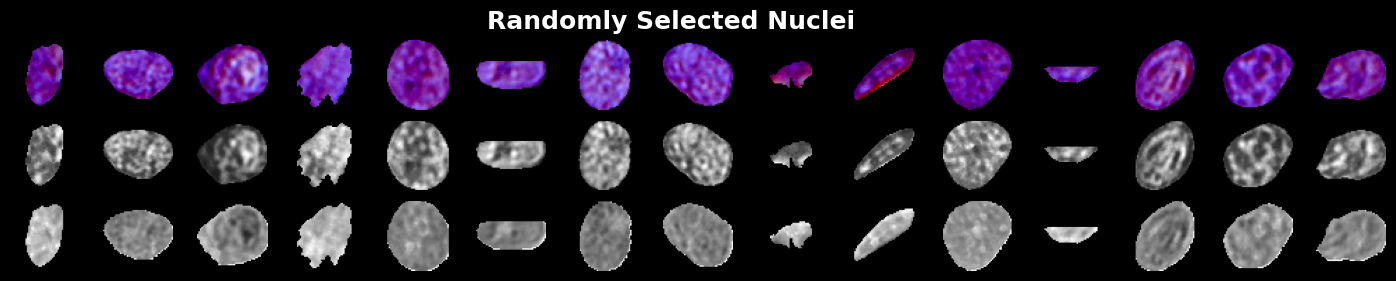

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import random

def show_nuclei_grids(nuclei_color, nuclei_gray_norm, nuclei_blue_inv, n_samples=36):
    """
    Randomly selects n_samples nuclei and shows three 6x6 grids:
    1. Color image
    2. Grayscale (normalized)
    3. Inverted Blue (masked)
    """

    # --- Randomly choose same nuclei indices ---
    total = min(len(nuclei_color), len(nuclei_gray_norm), len(nuclei_blue_inv))
    n_samples = min(n_samples, total)
    chosen_indices = random.sample(range(total), n_samples)

    color_subset = [nuclei_color[i] for i in chosen_indices]
    gray_subset  = [nuclei_gray_norm[i] for i in chosen_indices]
    blue_subset  = [nuclei_blue_inv[i] for i in chosen_indices]

    # --- Prepare figure ---
    fig, axes = plt.subplots(3, 15, figsize=(18, 3))
    fig.patch.set_facecolor('black')
    plt.subplots_adjust(hspace=0.15, wspace=0.05)

    # --- Helper to plot grid ---
    def plot_grid(axs, imgs, cmap=None):
        for i, ax in enumerate(axs.flat):
            if i >= len(imgs):
                ax.axis('off')
                continue
            img = imgs[i]
            if cmap == 'gray':
                img_disp = img / img.max() if img.max() > 0 else img
                ax.imshow(img_disp, cmap='gray')
            else:
                ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
            ax.axis('off')

    # --- Plot three rows ---
    plot_grid(axes[0, :], color_subset, cmap=None)
    plot_grid(axes[1, :], gray_subset, cmap='gray')
    plot_grid(axes[2, :], blue_subset, cmap='gray')

    # --- Add titles ---
    axes[0, 0].set_ylabel("Color Image", fontsize=12, color='white', weight='bold')
    axes[1, 0].set_ylabel("Grayscale (Normalized)", fontsize=12, color='white', weight='bold')
    axes[2, 0].set_ylabel("Inverted Blue", fontsize=12, color='white', weight='bold')

    fig.suptitle("Randomly Selected Nuclei ", fontsize=18, color='white', weight='bold')
    plt.show()

# ==== Example usage ====
show_nuclei_grids(nuclei_color, nuclei_gray_norm, nuclei_blue_inv, n_samples=36)


In [ ]:
import ipywidgets as widgets
from IPython.display import display, clear_output
from PIL import Image
import cv2
import numpy as np
from skimage.segmentation import find_boundaries
import io

# ==== Parameters ====
NUM_TO_SHOW = len(nuclei_color)  # using precomputed nuclei_color, etc.
BOX_SIZE = 100

# ==== Prepare tissue crops with red boundary centered in BOX_SIZE box ====
tissue_crops_box = []
for nuc_id in np.unique(mask)[1:NUM_TO_SHOW+1]:  # exclude background
    ys, xs = np.where(mask == nuc_id)
    if len(ys) == 0 or len(xs) == 0:
        continue

    minr, maxr = max(ys.min()-30, 0), min(ys.max()+30, image_rgb.shape[0])
    minc, maxc = max(xs.min()-30, 0), min(xs.max()+30, image_rgb.shape[1])

    tissue_crop = image_rgb[minr:maxr, minc:maxc].copy()

    # Fix: If RGBA (4 channels), drop alpha
    if tissue_crop.ndim == 3 and tissue_crop.shape[2] == 4:
        tissue_crop = tissue_crop[:, :, :3]

    # Find boundaries
    boundary = find_boundaries(mask[minr:maxr, minc:maxc] == nuc_id, mode='outer')

    # Apply boundary only if exists
    if boundary.any():
        tissue_crop[boundary] = [255, 0, 0]

    # Resize if needed
    h, w = tissue_crop.shape[:2]
    if max(h, w) > BOX_SIZE:
        scale = BOX_SIZE / max(h, w)
        tissue_crop = cv2.resize(tissue_crop, (int(w*scale), int(h*scale)))

    # Fix again: Ensure 3 channels after resize
    if tissue_crop.ndim == 3 and tissue_crop.shape[2] == 4:
        tissue_crop = tissue_crop[:, :, :3]

    # Center in black box
    h, w = tissue_crop.shape[:2]
    box_img = np.zeros((BOX_SIZE, BOX_SIZE, 3), dtype=np.uint8)
    y_offset = (BOX_SIZE - h) // 2
    x_offset = (BOX_SIZE - w) // 2
    box_img[y_offset:y_offset+h, x_offset:x_offset+w] = tissue_crop

    tissue_crops_box.append(box_img)

# ==== ipywidgets GUI ====
class NucleiReviewer:
    def __init__(self, tissue_crops, nuc_color, nuc_gray, nuc_blue):
        self.tissue_crops = tissue_crops
        self.nuc_color = nuc_color
        self.nuc_gray = nuc_gray
        self.nuc_blue = nuc_blue
        self.num = len(tissue_crops)
        self.accepted = [True] * self.num
        self.idx = 0

        # Create widgets
        self.output = widgets.Output()

        self.prev_btn = widgets.Button(description="Previous", button_style='info')
        self.next_btn = widgets.Button(description="Next", button_style='info')
        self.toggle_btn = widgets.Button(description="Accept/Reject", button_style='warning')
        self.save_btn = widgets.Button(description="Save Accepted", button_style='success')

        self.status_label = widgets.HTML(value="")

        # Button callbacks
        self.prev_btn.on_click(lambda b: self.prev_image())
        self.next_btn.on_click(lambda b: self.next_image())
        self.toggle_btn.on_click(lambda b: self.toggle())
        self.save_btn.on_click(lambda b: self.save())

        # Layout
        button_box = widgets.HBox([self.prev_btn, self.next_btn, self.toggle_btn, self.save_btn])
        self.ui = widgets.VBox([self.output, button_box, self.status_label])

    def show_image(self):
        with self.output:
            clear_output(wait=True)

            # Prepare images
            imgs = []
            labels = ["Tissue + Mask", "RGB Nucleus", "Normalized Gray", "Inverted Blue"]

            # Tissue crop
            tissue_img = Image.fromarray(self.tissue_crops[self.idx])
            tissue_img = tissue_img.resize((BOX_SIZE*2, BOX_SIZE*2))
            imgs.append(tissue_img)

            # RGB nucleus
            rgb_img = cv2.cvtColor(self.nuc_color[self.idx], cv2.COLOR_BGR2RGB)
            rgb_img = Image.fromarray(rgb_img).resize((BOX_SIZE*2, BOX_SIZE*2))
            imgs.append(rgb_img)

            # Normalized grayscale
            gray_img = self.nuc_gray[self.idx]
            gray_img_disp = gray_img / gray_img.max() if gray_img.max() > 0 else gray_img
            gray_img_disp = (gray_img_disp*255).astype(np.uint8)
            gray_img_disp = Image.fromarray(gray_img_disp).convert("L").resize((BOX_SIZE*2, BOX_SIZE*2))
            imgs.append(gray_img_disp)

            # Inverted blue
            blue_img = self.nuc_blue[self.idx]
            blue_img_disp = (blue_img/blue_img.max()*255).astype(np.uint8) if blue_img.max()>0 else (blue_img*255).astype(np.uint8)
            blue_img_disp = Image.fromarray(blue_img_disp).convert("L").resize((BOX_SIZE*2, BOX_SIZE*2))
            imgs.append(blue_img_disp)

            # Create horizontal layout
            total_width = BOX_SIZE * 2 * 4 + 30  # 4 images + spacing
            total_height = BOX_SIZE * 2 + 40  # image + label space
            combined = Image.new('RGB', (total_width, total_height), (30, 30, 30))

            from PIL import ImageDraw, ImageFont
            draw = ImageDraw.Draw(combined)

            for i, (img, label) in enumerate(zip(imgs, labels)):
                x_pos = i * (BOX_SIZE * 2 + 10)
                if img.mode == 'L':
                    img = img.convert('RGB')
                combined.paste(img, (x_pos, 30))
                draw.text((x_pos + 5, 5), label, fill=(255, 255, 255))

            display(combined)

        # Update status
        status = "✓ Accepted" if self.accepted[self.idx] else "✗ Rejected"
        color = "green" if self.accepted[self.idx] else "red"
        self.status_label.value = f'<h3 style="color:{color}">Nucleus {self.idx+1}/{self.num} - {status}</h3>'

        # Update button states
        self.prev_btn.disabled = (self.idx == 0)
        self.next_btn.disabled = (self.idx == self.num - 1)

    def next_image(self):
        if self.idx < self.num - 1:
            self.idx += 1
            self.show_image()

    def prev_image(self):
        if self.idx > 0:
            self.idx -= 1
            self.show_image()

    def toggle(self):
        self.accepted[self.idx] = not self.accepted[self.idx]
        self.show_image()

    def save(self):
        count = 0
        for i, img in enumerate(self.nuc_color):
            if self.accepted[i]:
                filename = f"nucleus_{i+1}.png"
                cv2.imwrite(filename, img)
                count += 1

        with self.output:
            print(f"\n✓ Saved {count} accepted nuclei!")

    def display(self):
        self.show_image()
        display(self.ui)

# ==== Run GUI ====
reviewer = NucleiReviewer(tissue_crops_box, nuclei_color, nuclei_gray_norm, nuclei_blue_inv)
reviewer.display()

In [ ]:
# !apt-get install -qq xvfb
# !pip install pyvirtualdisplay

# from pyvirtualdisplay import Display
# display = Display(visible=0, size=(1400, 900))
# display.start()

In [ ]:
# import tkinter as tk
# from tkinter import messagebox
# from PIL import Image, ImageTk
# import cv2
# import numpy as np
# from skimage.segmentation import find_boundaries

# # ==== Parameters ====
# NUM_TO_SHOW = len(nuclei_color)  # using precomputed nuclei_color, etc.
# BOX_SIZE = 100

# # ==== Prepare tissue crops with red boundary centered in BOX_SIZE box ====
# tissue_crops_box = []
# for nuc_id in np.unique(mask)[1:NUM_TO_SHOW+1]:  # exclude background
#     ys, xs = np.where(mask == nuc_id)
#     if len(ys) == 0 or len(xs) == 0:
#         continue

#     minr, maxr = max(ys.min()-30, 0), min(ys.max()+30, image_rgb.shape[0])
#     minc, maxc = max(xs.min()-30, 0), min(xs.max()+30, image_rgb.shape[1])

#     tissue_crop = image_rgb[minr:maxr, minc:maxc].copy()

#     # ---- FIX: If RGBA (4 channels), drop alpha ----
#     if tissue_crop.ndim == 3 and tissue_crop.shape[2] == 4:
#         tissue_crop = tissue_crop[:, :, :3]

#     # Find boundaries
#     boundary = find_boundaries(mask[minr:maxr, minc:maxc] == nuc_id, mode='outer')

#     # Apply boundary only if exists
#     if boundary.any():
#         tissue_crop[boundary] = [255, 0, 0]

#     # Resize if needed
#     h, w = tissue_crop.shape[:2]
#     if max(h, w) > BOX_SIZE:
#         scale = BOX_SIZE / max(h, w)
#         tissue_crop = cv2.resize(tissue_crop, (int(w*scale), int(h*scale)))

#     # ---- FIX AGAIN: Ensure 3 channels after resize ----
#     if tissue_crop.ndim == 3 and tissue_crop.shape[2] == 4:
#         tissue_crop = tissue_crop[:, :, :3]

#     # Center in black box
#     h, w = tissue_crop.shape[:2]
#     box_img = np.zeros((BOX_SIZE, BOX_SIZE, 3), dtype=np.uint8)
#     y_offset = (BOX_SIZE - h) // 2
#     x_offset = (BOX_SIZE - w) // 2
#     box_img[y_offset:y_offset+h, x_offset:x_offset+w] = tissue_crop

#     tissue_crops_box.append(box_img)


# # Accepted status
# accepted = [True]*NUM_TO_SHOW

# # ==== Tkinter GUI ====
# class NucleiGUI:
#     def __init__(self, master, tissue_crops, nuc_color, nuc_gray, nuc_blue):
#         self.master = master
#         self.tissue_crops = tissue_crops
#         self.nuc_color = nuc_color
#         self.nuc_gray = nuc_gray
#         self.nuc_blue = nuc_blue
#         self.num = len(tissue_crops)
#         self.accepted = [True]*self.num
#         self.idx = 0

#         self.master.title("Nuclei GUI")
#         self.canvases = []
#         for i in range(4):
#             canvas = tk.Canvas(master, width=BOX_SIZE*3, height=BOX_SIZE*3)
#             canvas.grid(row=0, column=i, padx=5, pady=5)
#             self.canvases.append(canvas)

#         # Buttons
#         btn_frame = tk.Frame(master)
#         btn_frame.grid(row=1, column=0, columnspan=4)
#         self.prev_btn = tk.Button(btn_frame, text="Previous", command=self.prev_image)
#         self.prev_btn.pack(side=tk.LEFT, padx=5)
#         self.next_btn = tk.Button(btn_frame, text="Next", command=self.next_image)
#         self.next_btn.pack(side=tk.LEFT, padx=5)
#         self.toggle_btn = tk.Button(btn_frame, text="Accept/Reject", command=self.toggle)
#         self.toggle_btn.pack(side=tk.LEFT, padx=5)
#         self.save_btn = tk.Button(btn_frame, text="Save Accepted", command=self.save)
#         self.save_btn.pack(side=tk.LEFT, padx=5)

#         self.status_label = tk.Label(master, text="")
#         self.status_label.grid(row=2, column=0, columnspan=4)

#         self.show_image()

#     def show_image(self):
#         # ---- Tissue crop (BOX_SIZE) ----
#         tissue_img = Image.fromarray(self.tissue_crops[self.idx])
#         tissue_img = tissue_img.resize((BOX_SIZE*3, BOX_SIZE*3))
#         self.tk_tissue = ImageTk.PhotoImage(tissue_img)
#         self.canvases[0].delete("all")
#         self.canvases[0].create_image(0, 0, anchor=tk.NW, image=self.tk_tissue)
#         self.canvases[0].create_text(5,5, anchor=tk.NW, text="Tissue + Mask", fill="white")

#         # ---- RGB nucleus ----
#         rgb_img = cv2.cvtColor(self.nuc_color[self.idx], cv2.COLOR_BGR2RGB)
#         rgb_img = Image.fromarray(rgb_img)
#         rgb_img = rgb_img.resize((BOX_SIZE*3, BOX_SIZE*3))
#         self.tk_rgb = ImageTk.PhotoImage(rgb_img)
#         self.canvases[1].delete("all")
#         self.canvases[1].create_image(0, 0, anchor=tk.NW, image=self.tk_rgb)
#         self.canvases[1].create_text(5,5, anchor=tk.NW, text="RGB Nucleus", fill="white")

#         # ---- Normalized grayscale ----
#         gray_img = self.nuc_gray[self.idx]
#         gray_img_disp = gray_img / gray_img.max() if gray_img.max() > 0 else gray_img
#         gray_img_disp = (gray_img_disp*255).astype(np.uint8)
#         gray_img_disp = Image.fromarray(gray_img_disp).convert("L").resize((BOX_SIZE*3, BOX_SIZE*3))
#         self.tk_gray = ImageTk.PhotoImage(gray_img_disp)
#         self.canvases[2].delete("all")
#         self.canvases[2].create_image(0, 0, anchor=tk.NW, image=self.tk_gray)
#         self.canvases[2].create_text(5,5, anchor=tk.NW, text="Normalized Gray", fill="white")

#         # ---- Inverted blue ----
#         blue_img = self.nuc_blue[self.idx]
#         blue_img_disp = (blue_img/blue_img.max()*255).astype(np.uint8) if blue_img.max()>0 else (blue_img*255).astype(np.uint8)
#         blue_img_disp = Image.fromarray(blue_img_disp).convert("L").resize((BOX_SIZE*3, BOX_SIZE*3))
#         self.tk_blue = ImageTk.PhotoImage(blue_img_disp)
#         self.canvases[3].delete("all")
#         self.canvases[3].create_image(0, 0, anchor=tk.NW, image=self.tk_blue)
#         self.canvases[3].create_text(5,5, anchor=tk.NW, text="Inverted Blue", fill="white")

#         status = "Accepted" if self.accepted[self.idx] else "Rejected"
#         self.status_label.config(text=f"Nucleus {self.idx+1}/{self.num} ({status})")

#     def next_image(self):
#         if self.idx < self.num - 1:
#             self.idx += 1
#             self.show_image()

#     def prev_image(self):
#         if self.idx > 0:
#             self.idx -= 1
#             self.show_image()

#     def toggle(self):
#         self.accepted[self.idx] = not self.accepted[self.idx]
#         self.show_image()

#     def save(self):
#         count = 0
#         for i, img in enumerate(self.nuc_color):
#             if self.accepted[i]:
#                 filename = f"nucleus_{i+1}.png"
#                 cv2.imwrite(filename, cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
#                 count += 1
#         messagebox.showinfo("Saved", f"Saved {count} nuclei!")

# # ==== Run GUI ====
# root = tk.Tk()
# gui = NucleiGUI(root, tissue_crops_box, nuclei_color, nuclei_gray_norm, nuclei_blue_inv)
# root.mainloop()
